In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [51]:
dataset=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [52]:
dataset.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [53]:
dataset.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [54]:
dataset.drop_duplicates(inplace=True)

In [55]:
dataset.shape

(7043, 21)

In [56]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [57]:
dataset['TotalCharges']=dataset['TotalCharges'].replace(' ' ,np.nan)

In [58]:
dataset['TotalCharges']=dataset['TotalCharges'].astype('float')

In [59]:
dataset['TotalCharges'].fillna(dataset['TotalCharges'].mean() , inplace=True)

/tmp/ipython-input-530822346.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['TotalCharges'].fillna(dataset['TotalCharges'].mean() , inplace=True)


In [60]:
dataset.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2265.000258
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1400.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [61]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Visualization

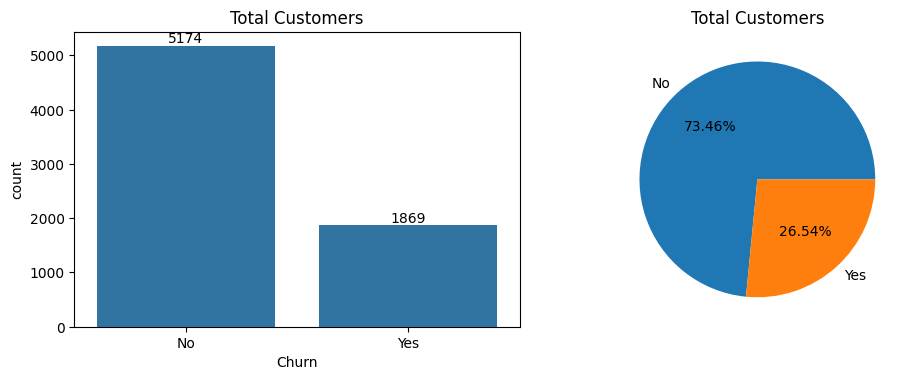

In [62]:
plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
plt.title('Total Customers')
ax=sns.countplot(data=dataset ,x='Churn')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.subplot(2,2,2)
gb=dataset.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index ,autopct='%1.2f%%')
plt.title('Total Customers')
plt.show()

/tmp/ipython-input-445594931.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.countplot(data=dataset , x='gender' ,color='red' ,hue='Churn')


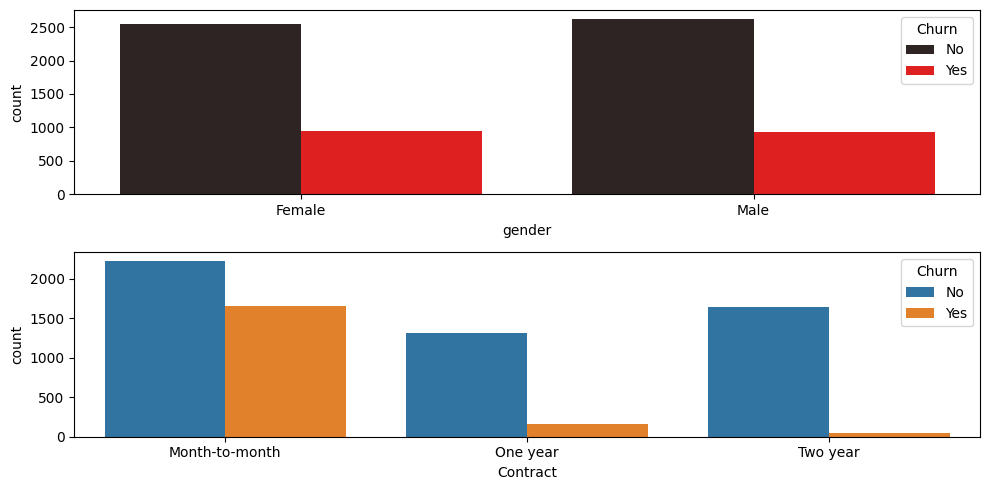

In [63]:
plt.figure(figsize=(10,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset , x='gender' ,color='red' ,hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='Contract' ,hue='Churn')
plt.tight_layout()

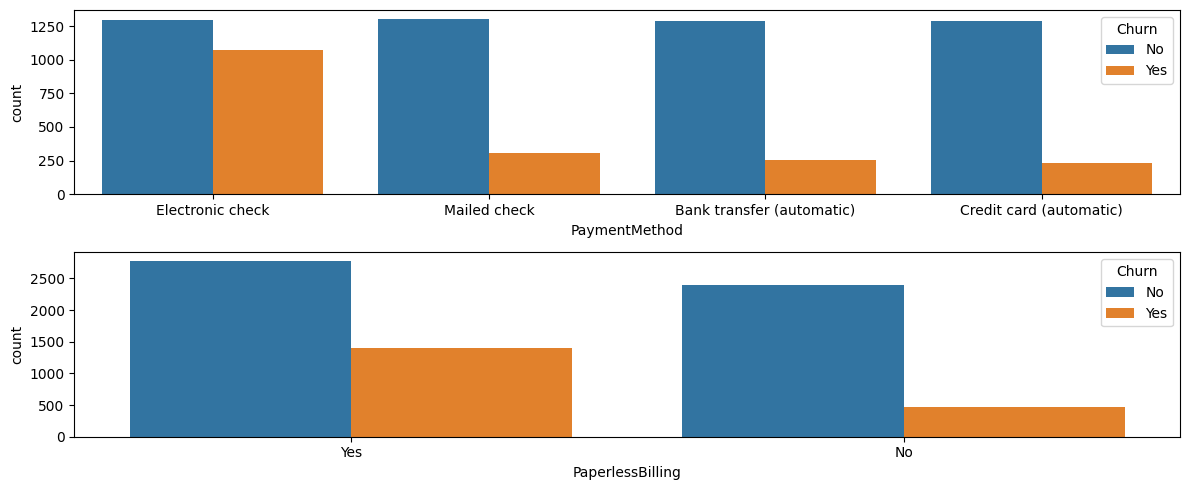

In [64]:
plt.figure(figsize=(12,5))
plt.subplot(2,1,1)
sns.countplot(data=dataset ,x='PaymentMethod',hue='Churn')
plt.tight_layout()
plt.subplot(2,1,2)
sns.countplot(data=dataset ,x='PaperlessBilling',hue='Churn')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Density')

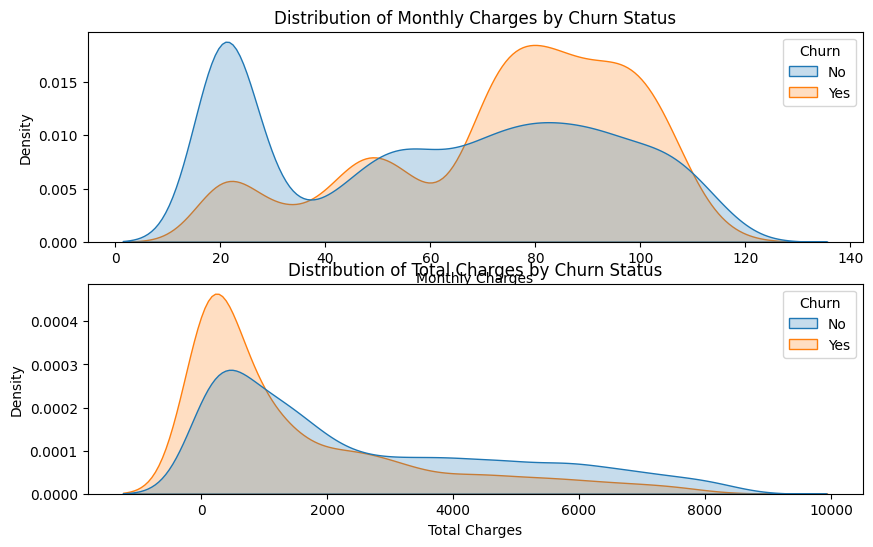

In [65]:
plt.figure(figsize=(10, 6))
plt.subplot(2,1,1)
sns.kdeplot(data=dataset, x='MonthlyCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Distribution of Monthly Charges by Churn Status')
plt.xlabel('Monthly Charges')
plt.ylabel('Density')

plt.subplot(2,1,2)
sns.kdeplot(data=dataset, x='TotalCharges', hue='Churn', fill=True, common_norm=False)
plt.title('Distribution of Total Charges by Churn Status')
plt.xlabel('Total Charges')
plt.ylabel('Density')


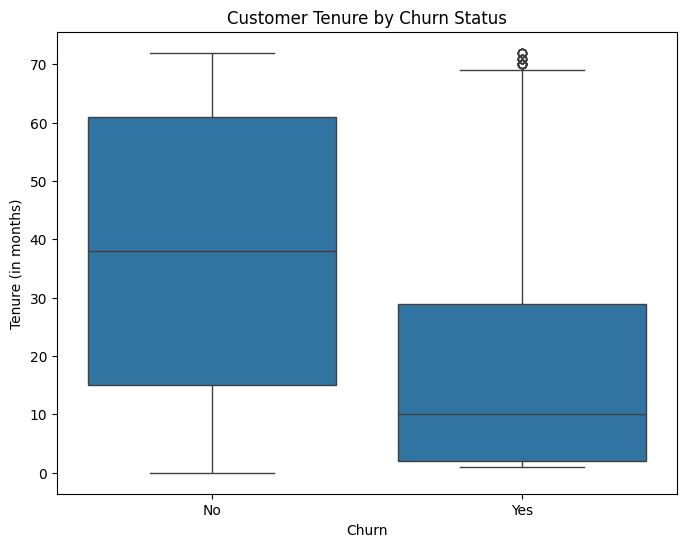

In [66]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='tenure', data=dataset)
plt.title('Customer Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (in months)')
plt.show()

## Model Creation Buliding

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from i

In [68]:
dataset.drop('customerID' , axis=1 , inplace=True)

In [69]:
input_data=dataset.drop('Churn',axis=1)
output=dataset['Churn']

In [119]:
Le=LabelEncoder()
output_en=Le.fit_transform(output)

In [120]:
input_data_en=pd.get_dummies(input_data)

In [121]:
input_data_en.isnull().sum()

,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
gender_Female,0
gender_Male,0
Partner_No,0
Partner_Yes,0
Dependents_No,0
Dependents_Yes,0


In [122]:
X_train, X_test, y_train, y_test = train_test_split(input_data_en, output_en, test_size=0.2, random_state=42)

In [156]:
pipeline_Lr=Pipeline([
    ('St' , StandardScaler()),
    ('Lr',LogisticRegression(random_state=42,class_weight='balanced'))
]
)

In [157]:
pipeline_Dtr=Pipeline([
    ('St' , StandardScaler()),
    ('Dtr',DecisionTreeClassifier(random_state=42,class_weight='balanced'))
]
)

In [158]:
pipeline_Rdf=Pipeline([
    ('St' , StandardScaler()),
    ('Rdf',RandomForestClassifier(random_state=42,class_weight='balanced'))
]
)

In [159]:
pipeline_ada=Pipeline([
    ('St' , StandardScaler()),
    ('Ada',AdaBoostClassifier(random_state=42))
]
)

In [160]:
pipeline_knn=Pipeline([
    ('St' , StandardScaler()),
    ('knn',KNeighborsClassifier())
]
)

In [161]:
pipeline_svm=Pipeline([
    ('St' , StandardScaler()),
    ('svm',SVC(class_weight='balanced'))
]
)

In [163]:
pipeline_xgb=Pipeline([
    ('St' , StandardScaler()),
    ('xbg',xgb.XGBClassifier())
]
)

In [154]:
pipeline_Lr.fit(X_train,y_train)

TypeError: All intermediate steps should be transformers and implement fit and transform or be the string 'passthrough' 'SMOTE()' (type <class 'imblearn.over_sampling._smote.base.SMOTE'>) doesn't

In [187]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [189]:
pipeline_Lr.fit(X_train_resampled, y_train_resampled)
print('Logistic Regression Classification Report:')
print(classification_report(y_test, pipeline_Lr.predict(X_test)))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      1036
           1       0.67      0.64      0.66       373

    accuracy                           0.82      1409
   macro avg       0.77      0.76      0.77      1409
weighted avg       0.82      0.82      0.82      1409



In [190]:
pipeline_Dtr.fit(X_train_resampled, y_train_resampled)
print('Decision Tree Classification Report:')
print(classification_report(y_test, pipeline_Dtr.predict(X_test)))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      1036
           1       0.50      0.53      0.51       373

    accuracy                           0.73      1409
   macro avg       0.66      0.67      0.67      1409
weighted avg       0.74      0.73      0.74      1409



In [191]:
pipeline_Rdf.fit(X_train_resampled, y_train_resampled)
print('Random Forest Classification Report:')
print(classification_report(y_test, pipeline_Rdf.predict(X_test)))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1036
           1       0.62      0.53      0.57       373

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



In [192]:
pipeline_ada.fit(X_train_resampled, y_train_resampled)
print('AdaBoost Classification Report:')
print(classification_report(y_test, pipeline_ada.predict(X_test)))

AdaBoost Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.83      0.86      1036
           1       0.60      0.70      0.65       373

    accuracy                           0.80      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.81      0.80      0.80      1409



In [193]:
pipeline_knn.fit(X_train_resampled, y_train_resampled)
print('KNeighbors Classification Report:')
print(classification_report(y_test, pipeline_knn.predict(X_test)))

KNeighbors Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      1036
           1       0.53      0.55      0.54       373

    accuracy                           0.75      1409
   macro avg       0.68      0.69      0.68      1409
weighted avg       0.75      0.75      0.75      1409



In [194]:
pipeline_svm.fit(X_train_resampled, y_train_resampled)
print('SVM Classification Report:')
print(classification_report(y_test, pipeline_svm.predict(X_test)))

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [195]:
pipeline_xgb.fit(X_train_resampled, y_train_resampled)
print('XGBoost Classification Report:')
print(classification_report(y_test, pipeline_xgb.predict(X_test)))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1036
           1       0.61      0.54      0.57       373

    accuracy                           0.79      1409
   macro avg       0.72      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [196]:
pipeline_Lr.score(X_test,y_test)*100

82.2569198012775

In [197]:
print('Classification Report' , classification_report(y_test ,pipeline_Lr.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.87      0.89      0.88      1036
           1       0.67      0.64      0.66       373

    accuracy                           0.82      1409
   macro avg       0.77      0.76      0.77      1409
weighted avg       0.82      0.82      0.82      1409



In [198]:
pipeline_Dtr.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()),
                ('Dtr',
                 DecisionTreeClassifier(class_weight='balanced',
                                        random_state=42))])

In [199]:
print('Classification Report' , classification_report(y_test ,pipeline_Dtr.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.81      0.80      0.81      1036
           1       0.47      0.48      0.48       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409



In [200]:
pipeline_ada.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()),
                ('Ada', AdaBoostClassifier(random_state=42))])

In [201]:
print('Classification Report' , classification_report(y_test ,pipeline_ada.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1036
           1       0.66      0.58      0.62       373

    accuracy                           0.81      1409
   macro avg       0.76      0.74      0.74      1409
weighted avg       0.80      0.81      0.81      1409



In [202]:
pipeline_Rdf.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()),
                ('Rdf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [203]:
print('Classification Report' , classification_report(y_test ,pipeline_Rdf.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [204]:
pipeline_knn.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()), ('knn', KNeighborsClassifier())])

In [205]:
print('Classification Report' , classification_report(y_test ,pipeline_Rdf.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.83      0.91      0.86      1036
           1       0.65      0.47      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



In [206]:
pipeline_svm.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()),
                ('svm', SVC(class_weight='balanced'))])

In [207]:
print('Classification Report' , classification_report(y_test ,pipeline_svm.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.91      0.74      0.81      1036
           1       0.52      0.80      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



In [208]:
pipeline_xgb.fit(X_train,y_train)

Pipeline(steps=[('St', StandardScaler()),
                ('xbg',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [209]:
print('Classification Report' , classification_report(y_test ,pipeline_xgb.predict(X_test)))

Classification Report               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1036
           1       0.62      0.52      0.56       373

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

